In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
import warnings


from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


KeyboardInterrupt: 

In [4]:
data = pd.read_csv('advertisement.csv', dtype=str)

In [ ]:

if data['Số tầng'].dtype == 'object':
    data['Số tầng'] = pd.to_numeric(data['Số tầng'], errors='coerce')
    
if data['Kinh độ'].dtype == 'object':
    data['Kinh độ'] = pd.to_numeric(data['Kinh độ'], errors='coerce')
if data['Vĩ độ'].dtype == 'object':
    data['Vĩ độ'] = pd.to_numeric(data['Vĩ độ'], errors='coerce')

if data['Ngày đăng'].dtype == 'object':
    data['Ngày đăng'] = pd.to_datetime(data['Ngày đăng'], errors='coerce')

if data['Đăng bởi Đối tác'].dtype == 'object':
    data['Đăng bởi Đối tác'] = data['Đăng bởi Đối tác'].map({'True': True, 'False': False, '1': True, '0': False})

if data['Có hướng ra đường'].dtype == 'object':
    data['Có hướng ra đường'] = data['Có hướng ra đường'].map({'True': True, 'False': False, '1': True, '0': False})
    
if data['Đơn giá (tr/m2)'].dtype == 'object':
    data['Đơn giá (tr/m2)'] = pd.to_numeric(
    data['Đơn giá (tr/m2)'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
).astype('float')

data['Số phòng ngủ'] = (data['Số phòng ngủ']
        .str.replace(r'(?i)\s*pn$', '', regex=True)
        .replace(r'(?i)^none$', np.nan, regex=True))

if data['Giá bán'].dtype == 'object':
    data['Giá bán'] = pd.to_numeric(
    data['Giá bán'].str.replace(r'[^0-9]', '', regex=True),
    errors='coerce'
).astype('Int64')
    data['Giá Bán'] = data['Giá bán']


if data['Chiều dài'].dtype == 'object':
    data['Chiều dài'] = pd.to_numeric(
    data['Chiều dài']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

if data['Chiều rộng'].dtype == 'object':
    data['Chiều rộng'] = pd.to_numeric(
    data['Chiều rộng']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)
   
if data['Diện tích'].dtype == 'object':
    data['Diện tích'] = pd.to_numeric(
    data['Diện tích']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)


if data['Số tầng'].dtype == 'object':
    data['Số tầng'] = pd.to_numeric(data['Số tầng'], errors='coerce')
    
if data['Kinh độ'].dtype == 'object':
    data['Kinh độ'] = pd.to_numeric(data['Kinh độ'], errors='coerce')
if data['Vĩ độ'].dtype == 'object':
    data['Vĩ độ'] = pd.to_numeric(data['Vĩ độ'], errors='coerce')

if data['Ngày đăng'].dtype == 'object':
    data['Ngày đăng'] = pd.to_datetime(data['Ngày đăng'], errors='coerce')

if data['Đăng bởi Đối tác'].dtype == 'object':
    data['Đăng bởi Đối tác'] = data['Đăng bởi Đối tác'].map({'True': True, 'False': False, '1': True, '0': False})

if data['Có hướng ra đường'].dtype == 'object':
    data['Có hướng ra đường'] = data['Có hướng ra đường'].map({'True': True, 'False': False, '1': True, '0': False})
    
if data['Đơn giá (tr/m2)'].dtype == 'object':
    data['Đơn giá (tr/m2)'] = pd.to_numeric(
    data['Đơn giá (tr/m2)'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
).astype('float')

data['Số phòng ngủ'] = (data['Số phòng ngủ']
        .str.replace(r'(?i)\s*pn$', '', regex=True)
        .replace(r'(?i)^none$', np.nan, regex=True))

if data['Giá bán'].dtype == 'object':
    data['Giá bán'] = pd.to_numeric(
    data['Giá bán'].str.replace(r'[^0-9]', '', regex=True),
    errors='coerce'
).astype('Int64')
    data['Giá Bán'] = data['Giá bán']


if data['Chiều dài'].dtype == 'object':
    data['Chiều dài'] = pd.to_numeric(
    data['Chiều dài']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

if data['Chiều rộng'].dtype == 'object':
    data['Chiều rộng'] = pd.to_numeric(
    data['Chiều rộng']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)
   
if data['Diện tích'].dtype == 'object':
    data['Diện tích'] = pd.to_numeric(
    data['Diện tích']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)


def fill_area(df):
    df = df.copy()

    area_col = 'Diện tích'
    length_col = 'Chiều dài'
    width_col = 'Chiều rộng'
    unit_price_col = 'Đơn giá (tr/m2)'
    price_col = 'Giá bán'
    type_col = 'Loại hình'
    district_col = 'Huyện/Quận cũ'

    if 'Phường mới' in df.columns and 'Phường/Xã cũ' in df.columns:
        df['_Khu vực'] = df['Phường mới'].fillna(df['Phường/Xã cũ'])
    elif 'Phường mới' in df.columns:
        df['_Khu vực'] = df['Phường mới']
    else:
        df['_Khu vực'] = df['Phường/Xã cũ']

    df['_Khu vực'] = df['_Khu vực'].fillna(df[district_col])

    for col in [area_col, length_col, width_col, unit_price_col, price_col]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Bước 1: điền bằng chiều dài * chiều rộng
    mask_step_1 = (
        df[area_col].isna()
        & df[length_col].gt(0)
        & df[width_col].gt(0)
    )
    df.loc[mask_step_1, area_col] = (
        df.loc[mask_step_1, length_col] * df.loc[mask_step_1, width_col]
    )

    # Bước 2: chỉ điền những dòng còn thiếu sau bước 1
    mask_step_2 = (
        df[area_col].isna()
        & df[price_col].gt(0)
        & df[unit_price_col].gt(0)
    )
    df.loc[mask_step_2, area_col] = (
        df.loc[mask_step_2, price_col]
        / (df.loc[mask_step_2, unit_price_col] * 1_000_000)
    )

    # Bước 3: chỉ điền những dòng còn thiếu sau bước 2
    mask_step_3 = df[area_col].isna()
    group_mean = (
        df.groupby([type_col, district_col, '_Khu vực'])[area_col]
        .transform('mean')
    )
    df.loc[mask_step_3, area_col] = group_mean[mask_step_3]

    return df.drop(columns=['_Khu vực'])

data = fill_area(data)

In [ ]:

if data['Số tầng'].dtype == 'object':
    data['Số tầng'] = pd.to_numeric(data['Số tầng'], errors='coerce')
    
if data['Kinh độ'].dtype == 'object':
    data['Kinh độ'] = pd.to_numeric(data['Kinh độ'], errors='coerce')
if data['Vĩ độ'].dtype == 'object':
    data['Vĩ độ'] = pd.to_numeric(data['Vĩ độ'], errors='coerce')

if data['Ngày đăng'].dtype == 'object':
    data['Ngày đăng'] = pd.to_datetime(data['Ngày đăng'], errors='coerce')

if data['Đăng bởi Đối tác'].dtype == 'object':
    data['Đăng bởi Đối tác'] = data['Đăng bởi Đối tác'].map({'True': True, 'False': False, '1': True, '0': False})

if data['Có hướng ra đường'].dtype == 'object':
    data['Có hướng ra đường'] = data['Có hướng ra đường'].map({'True': True, 'False': False, '1': True, '0': False})
    
if data['Đơn giá (tr/m2)'].dtype == 'object':
    data['Đơn giá (tr/m2)'] = pd.to_numeric(
    data['Đơn giá (tr/m2)'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
).astype('float')

data['Số phòng ngủ'] = (data['Số phòng ngủ']
        .str.replace(r'(?i)\s*pn$', '', regex=True)
        .replace(r'(?i)^none$', np.nan, regex=True))

if data['Giá bán'].dtype == 'object':
    data['Giá bán'] = pd.to_numeric(
    data['Giá bán'].str.replace(r'[^0-9]', '', regex=True),
    errors='coerce'
).astype('Int64')
    data['Giá Bán'] = data['Giá bán']


if data['Chiều dài'].dtype == 'object':
    data['Chiều dài'] = pd.to_numeric(
    data['Chiều dài']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

if data['Chiều rộng'].dtype == 'object':
    data['Chiều rộng'] = pd.to_numeric(
    data['Chiều rộng']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)
   
if data['Diện tích'].dtype == 'object':
    data['Diện tích'] = pd.to_numeric(
    data['Diện tích']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)


if data['Số tầng'].dtype == 'object':
    data['Số tầng'] = pd.to_numeric(data['Số tầng'], errors='coerce')
    
if data['Kinh độ'].dtype == 'object':
    data['Kinh độ'] = pd.to_numeric(data['Kinh độ'], errors='coerce')
if data['Vĩ độ'].dtype == 'object':
    data['Vĩ độ'] = pd.to_numeric(data['Vĩ độ'], errors='coerce')

if data['Ngày đăng'].dtype == 'object':
    data['Ngày đăng'] = pd.to_datetime(data['Ngày đăng'], errors='coerce')

if data['Đăng bởi Đối tác'].dtype == 'object':
    data['Đăng bởi Đối tác'] = data['Đăng bởi Đối tác'].map({'True': True, 'False': False, '1': True, '0': False})

if data['Có hướng ra đường'].dtype == 'object':
    data['Có hướng ra đường'] = data['Có hướng ra đường'].map({'True': True, 'False': False, '1': True, '0': False})
    
if data['Đơn giá (tr/m2)'].dtype == 'object':
    data['Đơn giá (tr/m2)'] = pd.to_numeric(
    data['Đơn giá (tr/m2)'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
).astype('float')

data['Số phòng ngủ'] = (data['Số phòng ngủ']
        .str.replace(r'(?i)\s*pn$', '', regex=True)
        .replace(r'(?i)^none$', np.nan, regex=True))

if data['Giá bán'].dtype == 'object':
    data['Giá bán'] = pd.to_numeric(
    data['Giá bán'].str.replace(r'[^0-9]', '', regex=True),
    errors='coerce'
).astype('Int64')
    data['Giá Bán'] = data['Giá bán']


if data['Chiều dài'].dtype == 'object':
    data['Chiều dài'] = pd.to_numeric(
    data['Chiều dài']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

if data['Chiều rộng'].dtype == 'object':
    data['Chiều rộng'] = pd.to_numeric(
    data['Chiều rộng']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)
   
if data['Diện tích'].dtype == 'object':
    data['Diện tích'] = pd.to_numeric(
    data['Diện tích']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)


def fill_area(df):
    df = df.copy()

    area_col = 'Diện tích'
    length_col = 'Chiều dài'
    width_col = 'Chiều rộng'
    unit_price_col = 'Đơn giá (tr/m2)'
    price_col = 'Giá bán'
    type_col = 'Loại hình'
    district_col = 'Huyện/Quận cũ'

    if 'Phường mới' in df.columns and 'Phường/Xã cũ' in df.columns:
        df['_Khu vực'] = df['Phường mới'].fillna(df['Phường/Xã cũ'])
    elif 'Phường mới' in df.columns:
        df['_Khu vực'] = df['Phường mới']
    else:
        df['_Khu vực'] = df['Phường/Xã cũ']

    df['_Khu vực'] = df['_Khu vực'].fillna(df[district_col])

    for col in [area_col, length_col, width_col, unit_price_col, price_col]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Bước 1: điền bằng chiều dài * chiều rộng
    mask_step_1 = (
        df[area_col].isna()
        & df[length_col].gt(0)
        & df[width_col].gt(0)
    )
    df.loc[mask_step_1, area_col] = (
        df.loc[mask_step_1, length_col] * df.loc[mask_step_1, width_col]
    )

    # Bước 2: chỉ điền những dòng còn thiếu sau bước 1
    mask_step_2 = (
        df[area_col].isna()
        & df[price_col].gt(0)
        & df[unit_price_col].gt(0)
    )
    df.loc[mask_step_2, area_col] = (
        df.loc[mask_step_2, price_col]
        / (df.loc[mask_step_2, unit_price_col] * 1_000_000)
    )

    # Bước 3: chỉ điền những dòng còn thiếu sau bước 2
    mask_step_3 = df[area_col].isna()
    group_mean = (
        df.groupby([type_col, district_col, '_Khu vực'])[area_col]
        .transform('mean')
    )
    df.loc[mask_step_3, area_col] = group_mean[mask_step_3]

    return df.drop(columns=['_Khu vực'])

data = fill_area(data)

def fill_missing_coordinates(df):
    df = df.copy()

    lat_col = 'Vĩ độ'
    lon_col = 'Kinh độ'
    city_col = 'Tỉnh/Thành phố cũ'
    district_col = 'Huyện/Quận cũ'
    ward_old_col = 'Phường/Xã cũ'
    ward_new_col = 'Phường mới'
    house_col = 'Số nhà'
    street_col = 'Đường'

    df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
    df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')

    def clean_text(x):
        if pd.isna(x):
            return None
        s = str(x).strip()
        if s == '' or s.lower() in {'nan', 'none', 'null'}:
            return None
        return s

    # Ưu tiên Phường mới, nếu trống thì dùng Phường/Xã cũ
    df['_ward_used'] = df[ward_new_col].apply(clean_text)
    mask_ward_missing = df['_ward_used'].isna()
    df.loc[mask_ward_missing, '_ward_used'] = df.loc[mask_ward_missing, ward_old_col].apply(clean_text)

    def build_address(row):
        parts = [
            clean_text(row[house_col]),
            clean_text(row[street_col]),
            clean_text(row['_ward_used']),
            clean_text(row[district_col]),
            clean_text(row[city_col]),
            'Vietnam'
        ]
        parts = [p for p in parts if p is not None]
        return ', '.join(dict.fromkeys(parts)) if parts else None

    df['_full_address'] = df.apply(build_address, axis=1)

    # Chỉ geocode những dòng thiếu lat/lon
    missing_mask = df[lat_col].isna() | df[lon_col].isna()
    addresses_to_lookup = (
        df.loc[missing_mask, '_full_address']
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    geolocator = Nominatim(user_agent='real_estate_fill_missing_coordinates')
    geocode = RateLimiter(
        geolocator.geocode,
        min_delay_seconds=1.0,
        max_retries=2,
        error_wait_seconds=3.0,
        swallow_exceptions=True
    )

    geo_cache = {}

    for address in addresses_to_lookup:
        location = geocode(
            address,
            country_codes='vn',
            language='vi',
            exactly_one=True,
            timeout=10
        )
        if location is not None:
            geo_cache[address] = (location.latitude, location.longitude)
        else:
            geo_cache[address] = (np.nan, np.nan)

    df['_geo_lat'] = df['_full_address'].map(
        lambda x: geo_cache.get(x, (np.nan, np.nan))[0] if pd.notna(x) else np.nan
    )
    df['_geo_lon'] = df['_full_address'].map(
        lambda x: geo_cache.get(x, (np.nan, np.nan))[1] if pd.notna(x) else np.nan
    )

    before_missing = (df[lat_col].isna() | df[lon_col].isna()).sum()

    # Điền từ geocode trước
    lat_fill_mask = df[lat_col].isna() & df['_geo_lat'].notna()
    lon_fill_mask = df[lon_col].isna() & df['_geo_lon'].notna()

    df.loc[lat_fill_mask, lat_col] = df.loc[lat_fill_mask, '_geo_lat']
    df.loc[lon_fill_mask, lon_col] = df.loc[lon_fill_mask, '_geo_lon']

    after_geocode_missing = (df[lat_col].isna() | df[lon_col].isna()).sum()

    # Nếu geocode không ra thì dùng trung bình theo khu vực
    def fill_by_group_mean(group_cols):
        lat_mean = df.groupby(group_cols)[lat_col].transform('mean')
        lon_mean = df.groupby(group_cols)[lon_col].transform('mean')

        lat_mask = df[lat_col].isna() & lat_mean.notna()
        lon_mask = df[lon_col].isna() & lon_mean.notna()

        df.loc[lat_mask, lat_col] = lat_mean[lat_mask]
        df.loc[lon_mask, lon_col] = lon_mean[lon_mask]

    # Từ chi tiết đến tổng quát
    group_levels = [
        [street_col, '_ward_used', district_col, city_col],
        ['_ward_used', district_col, city_col],
        [district_col, city_col],
        [city_col]
    ]

    for group_cols in group_levels:
        fill_by_group_mean(group_cols)

    # Fallback cuối cùng: trung bình toàn bộ dataset
    df[lat_col] = df[lat_col].fillna(df[lat_col].mean())
    df[lon_col] = df[lon_col].fillna(df[lon_col].mean())

    after_all_missing = (df[lat_col].isna() | df[lon_col].isna()).sum()

    print(f"Số dòng thiếu tọa độ ban đầu: {before_missing}")
    print(f"Số dòng còn thiếu sau geocode: {after_geocode_missing}")
    print(f"Số dòng còn thiếu sau khi fill trung bình: {after_all_missing}")

    df = df.drop(columns=['_ward_used', '_full_address', '_geo_lat', '_geo_lon'])

    return df



Model benchmark results


,Combo,Model,Num Features,Train Rows,Test Rows,MAE (bn VND),RMSE (bn VND),MAPE (%),RMSLE,R2,Status
0,Combo_3,Ridge Regression,10,30825,7707,8.7373,59.7447,251.4941,7.1910,-0.0203,OK
1,Combo_1,Ridge Regression,9,30825,7707,8.7659,59.7537,254.0414,7.3146,-0.0206,OK
2,Combo_2,Ridge Regression,11,30825,7707,8.7672,59.7549,254.4808,7.3219,-0.0207,OK
3,Combo_3,Lasso Regression,10,30825,7707,8.7646,59.7826,251.7761,7.2279,-0.0216,OK
4,Combo_3,Linear Regression,10,30825,7707,8.7644,59.7826,251.7522,7.2350,-0.0216,OK
5,Combo_1,Linear Regression,9,30825,7707,8.7926,59.7917,254.5675,7.3747,-0.0219,OK
6,Combo_1,Lasso Regression,9,30825,7707,8.7931,59.7918,254.5642,7.3714,-0.0219,OK
7,Combo_2,Linear Regression,11,30825,7707,8.7940,59.7929,255.0087,7.3629,-0.0220,OK
8,Combo_2,Lasso Regression,11,30825,7707,8.7942,59.7930,255.0011,7.3668,-0.0220,OK
9,Combo_4,Ridge Regression,13,30825,7707,10.4327,64.2410,250.6550,10.2114,-0.1797,OK


Skipped / failed models


,Combo,Model,Status,Missing Requested Features
3,Combo_1,Logistic Regression,SKIPPED: Giá bán là biến liên tục; Logistic Re...,
4,Combo_1,Softmax Regression,SKIPPED: Giá bán là biến liên tục; Softmax Reg...,
10,Combo_2,Logistic Regression,SKIPPED: Giá bán là biến liên tục; Logistic Re...,
11,Combo_2,Softmax Regression,SKIPPED: Giá bán là biến liên tục; Softmax Reg...,
17,Combo_3,Logistic Regression,SKIPPED: Giá bán là biến liên tục; Logistic Re...,
18,Combo_3,Softmax Regression,SKIPPED: Giá bán là biến liên tục; Softmax Reg...,
24,Combo_4,Logistic Regression,SKIPPED: Giá bán là biến liên tục; Logistic Re...,
25,Combo_4,Softmax Regression,SKIPPED: Giá bán là biến liên tục; Softmax Reg...,


Best model for each combo


,Combo,Model,Num Features,Train Rows,Test Rows,MAE (bn VND),RMSE (bn VND),MAPE (%),RMSLE,R2,Status
0,Combo_1,Ridge Regression,9,30825,7707,8.7659,59.7537,254.0414,7.3146,-0.0206,OK
1,Combo_2,Ridge Regression,11,30825,7707,8.7672,59.7549,254.4808,7.3219,-0.0207,OK
2,Combo_3,Ridge Regression,10,30825,7707,8.7373,59.7447,251.4941,7.1910,-0.0203,OK
3,Combo_4,Ridge Regression,13,30825,7707,10.4327,64.2410,250.6550,10.2114,-0.1797,OK


Best overall: Combo_3 | Ridge Regression


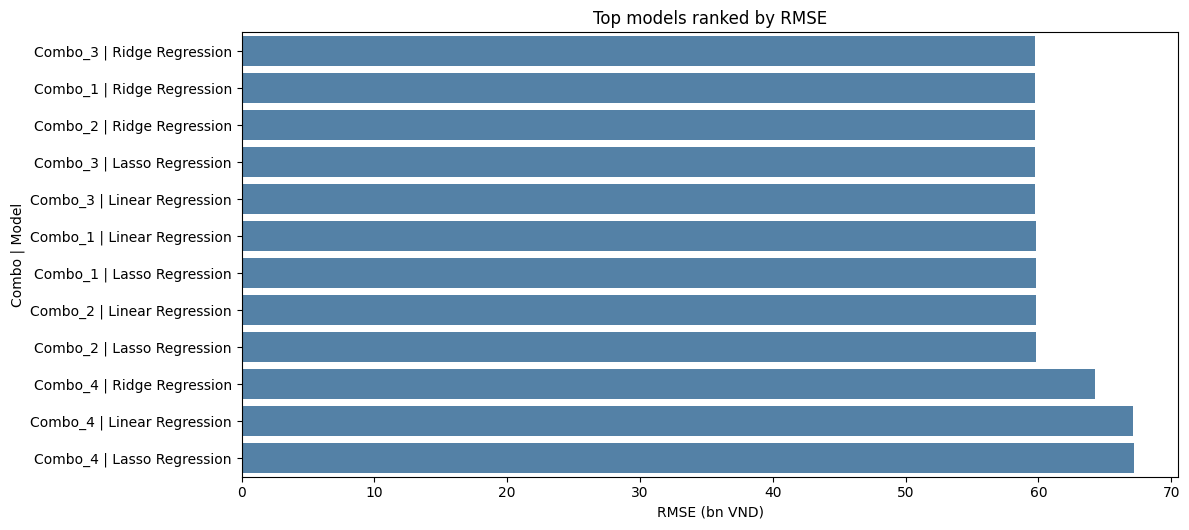

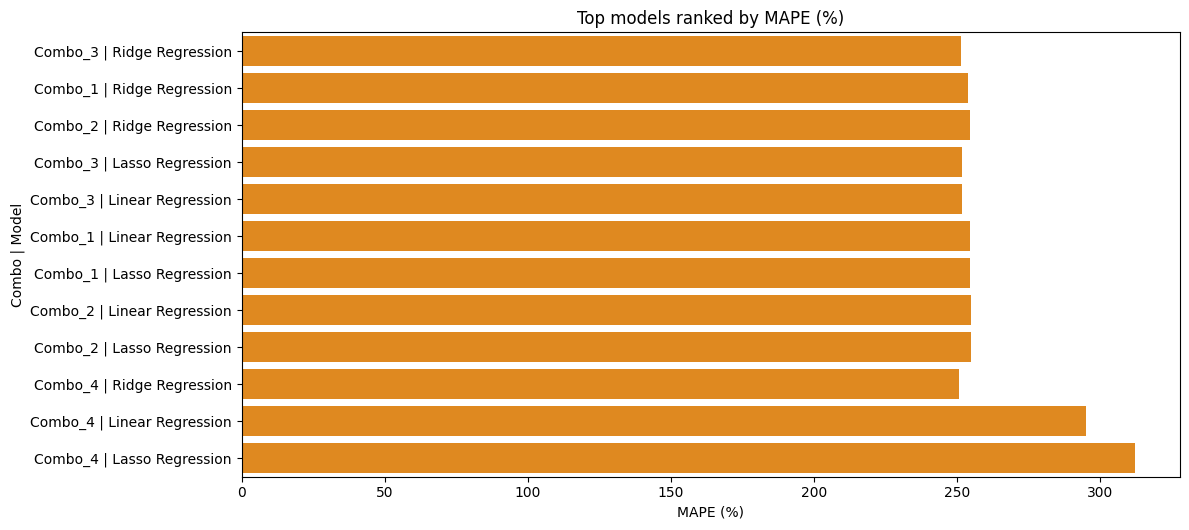

In [ ]:

if data['Số tầng'].dtype == 'object':
    data['Số tầng'] = pd.to_numeric(data['Số tầng'], errors='coerce')
    
if data['Kinh độ'].dtype == 'object':
    data['Kinh độ'] = pd.to_numeric(data['Kinh độ'], errors='coerce')
if data['Vĩ độ'].dtype == 'object':
    data['Vĩ độ'] = pd.to_numeric(data['Vĩ độ'], errors='coerce')

if data['Ngày đăng'].dtype == 'object':
    data['Ngày đăng'] = pd.to_datetime(data['Ngày đăng'], errors='coerce')

if data['Đăng bởi Đối tác'].dtype == 'object':
    data['Đăng bởi Đối tác'] = data['Đăng bởi Đối tác'].map({'True': True, 'False': False, '1': True, '0': False})

if data['Có hướng ra đường'].dtype == 'object':
    data['Có hướng ra đường'] = data['Có hướng ra đường'].map({'True': True, 'False': False, '1': True, '0': False})
    
if data['Đơn giá (tr/m2)'].dtype == 'object':
    data['Đơn giá (tr/m2)'] = pd.to_numeric(
    data['Đơn giá (tr/m2)'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
).astype('float')

data['Số phòng ngủ'] = (data['Số phòng ngủ']
        .str.replace(r'(?i)\s*pn$', '', regex=True)
        .replace(r'(?i)^none$', np.nan, regex=True))

if data['Giá bán'].dtype == 'object':
    data['Giá bán'] = pd.to_numeric(
    data['Giá bán'].str.replace(r'[^0-9]', '', regex=True),
    errors='coerce'
).astype('Int64')
    data['Giá Bán'] = data['Giá bán']


if data['Chiều dài'].dtype == 'object':
    data['Chiều dài'] = pd.to_numeric(
    data['Chiều dài']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

if data['Chiều rộng'].dtype == 'object':
    data['Chiều rộng'] = pd.to_numeric(
    data['Chiều rộng']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)
   
if data['Diện tích'].dtype == 'object':
    data['Diện tích'] = pd.to_numeric(
    data['Diện tích']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)


if data['Số tầng'].dtype == 'object':
    data['Số tầng'] = pd.to_numeric(data['Số tầng'], errors='coerce')
    
if data['Kinh độ'].dtype == 'object':
    data['Kinh độ'] = pd.to_numeric(data['Kinh độ'], errors='coerce')
if data['Vĩ độ'].dtype == 'object':
    data['Vĩ độ'] = pd.to_numeric(data['Vĩ độ'], errors='coerce')

if data['Ngày đăng'].dtype == 'object':
    data['Ngày đăng'] = pd.to_datetime(data['Ngày đăng'], errors='coerce')

if data['Đăng bởi Đối tác'].dtype == 'object':
    data['Đăng bởi Đối tác'] = data['Đăng bởi Đối tác'].map({'True': True, 'False': False, '1': True, '0': False})

if data['Có hướng ra đường'].dtype == 'object':
    data['Có hướng ra đường'] = data['Có hướng ra đường'].map({'True': True, 'False': False, '1': True, '0': False})
    
if data['Đơn giá (tr/m2)'].dtype == 'object':
    data['Đơn giá (tr/m2)'] = pd.to_numeric(
    data['Đơn giá (tr/m2)'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
).astype('float')

data['Số phòng ngủ'] = (data['Số phòng ngủ']
        .str.replace(r'(?i)\s*pn$', '', regex=True)
        .replace(r'(?i)^none$', np.nan, regex=True))

if data['Giá bán'].dtype == 'object':
    data['Giá bán'] = pd.to_numeric(
    data['Giá bán'].str.replace(r'[^0-9]', '', regex=True),
    errors='coerce'
).astype('Int64')
    data['Giá Bán'] = data['Giá bán']


if data['Chiều dài'].dtype == 'object':
    data['Chiều dài'] = pd.to_numeric(
    data['Chiều dài']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

if data['Chiều rộng'].dtype == 'object':
    data['Chiều rộng'] = pd.to_numeric(
    data['Chiều rộng']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)
   
if data['Diện tích'].dtype == 'object':
    data['Diện tích'] = pd.to_numeric(
    data['Diện tích']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)


def fill_area(df):
    df = df.copy()

    area_col = 'Diện tích'
    length_col = 'Chiều dài'
    width_col = 'Chiều rộng'
    unit_price_col = 'Đơn giá (tr/m2)'
    price_col = 'Giá bán'
    type_col = 'Loại hình'
    district_col = 'Huyện/Quận cũ'

    if 'Phường mới' in df.columns and 'Phường/Xã cũ' in df.columns:
        df['_Khu vực'] = df['Phường mới'].fillna(df['Phường/Xã cũ'])
    elif 'Phường mới' in df.columns:
        df['_Khu vực'] = df['Phường mới']
    else:
        df['_Khu vực'] = df['Phường/Xã cũ']

    df['_Khu vực'] = df['_Khu vực'].fillna(df[district_col])

    for col in [area_col, length_col, width_col, unit_price_col, price_col]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Bước 1: điền bằng chiều dài * chiều rộng
    mask_step_1 = (
        df[area_col].isna()
        & df[length_col].gt(0)
        & df[width_col].gt(0)
    )
    df.loc[mask_step_1, area_col] = (
        df.loc[mask_step_1, length_col] * df.loc[mask_step_1, width_col]
    )

    # Bước 2: chỉ điền những dòng còn thiếu sau bước 1
    mask_step_2 = (
        df[area_col].isna()
        & df[price_col].gt(0)
        & df[unit_price_col].gt(0)
    )
    df.loc[mask_step_2, area_col] = (
        df.loc[mask_step_2, price_col]
        / (df.loc[mask_step_2, unit_price_col] * 1_000_000)
    )

    # Bước 3: chỉ điền những dòng còn thiếu sau bước 2
    mask_step_3 = df[area_col].isna()
    group_mean = (
        df.groupby([type_col, district_col, '_Khu vực'])[area_col]
        .transform('mean')
    )
    df.loc[mask_step_3, area_col] = group_mean[mask_step_3]

    return df.drop(columns=['_Khu vực'])

data = fill_area(data)

def fill_missing_coordinates(df):
    df = df.copy()

    lat_col = 'Vĩ độ'
    lon_col = 'Kinh độ'
    city_col = 'Tỉnh/Thành phố cũ'
    district_col = 'Huyện/Quận cũ'
    ward_old_col = 'Phường/Xã cũ'
    ward_new_col = 'Phường mới'
    house_col = 'Số nhà'
    street_col = 'Đường'

    df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
    df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')

    def clean_text(x):
        if pd.isna(x):
            return None
        s = str(x).strip()
        if s == '' or s.lower() in {'nan', 'none', 'null'}:
            return None
        return s

    # Ưu tiên Phường mới, nếu trống thì dùng Phường/Xã cũ
    df['_ward_used'] = df[ward_new_col].apply(clean_text)
    mask_ward_missing = df['_ward_used'].isna()
    df.loc[mask_ward_missing, '_ward_used'] = df.loc[mask_ward_missing, ward_old_col].apply(clean_text)

    def build_address(row):
        parts = [
            clean_text(row[house_col]),
            clean_text(row[street_col]),
            clean_text(row['_ward_used']),
            clean_text(row[district_col]),
            clean_text(row[city_col]),
            'Vietnam'
        ]
        parts = [p for p in parts if p is not None]
        return ', '.join(dict.fromkeys(parts)) if parts else None

    df['_full_address'] = df.apply(build_address, axis=1)

    # Chỉ geocode những dòng thiếu lat/lon
    missing_mask = df[lat_col].isna() | df[lon_col].isna()
    addresses_to_lookup = (
        df.loc[missing_mask, '_full_address']
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    geolocator = Nominatim(user_agent='real_estate_fill_missing_coordinates')
    geocode = RateLimiter(
        geolocator.geocode,
        min_delay_seconds=1.0,
        max_retries=2,
        error_wait_seconds=3.0,
        swallow_exceptions=True
    )

    geo_cache = {}

    for address in addresses_to_lookup:
        location = geocode(
            address,
            country_codes='vn',
            language='vi',
            exactly_one=True,
            timeout=10
        )
        if location is not None:
            geo_cache[address] = (location.latitude, location.longitude)
        else:
            geo_cache[address] = (np.nan, np.nan)

    df['_geo_lat'] = df['_full_address'].map(
        lambda x: geo_cache.get(x, (np.nan, np.nan))[0] if pd.notna(x) else np.nan
    )
    df['_geo_lon'] = df['_full_address'].map(
        lambda x: geo_cache.get(x, (np.nan, np.nan))[1] if pd.notna(x) else np.nan
    )

    before_missing = (df[lat_col].isna() | df[lon_col].isna()).sum()

    # Điền từ geocode trước
    lat_fill_mask = df[lat_col].isna() & df['_geo_lat'].notna()
    lon_fill_mask = df[lon_col].isna() & df['_geo_lon'].notna()

    df.loc[lat_fill_mask, lat_col] = df.loc[lat_fill_mask, '_geo_lat']
    df.loc[lon_fill_mask, lon_col] = df.loc[lon_fill_mask, '_geo_lon']

    after_geocode_missing = (df[lat_col].isna() | df[lon_col].isna()).sum()

    # Nếu geocode không ra thì dùng trung bình theo khu vực
    def fill_by_group_mean(group_cols):
        lat_mean = df.groupby(group_cols)[lat_col].transform('mean')
        lon_mean = df.groupby(group_cols)[lon_col].transform('mean')

        lat_mask = df[lat_col].isna() & lat_mean.notna()
        lon_mask = df[lon_col].isna() & lon_mean.notna()

        df.loc[lat_mask, lat_col] = lat_mean[lat_mask]
        df.loc[lon_mask, lon_col] = lon_mean[lon_mask]

    # Từ chi tiết đến tổng quát
    group_levels = [
        [street_col, '_ward_used', district_col, city_col],
        ['_ward_used', district_col, city_col],
        [district_col, city_col],
        [city_col]
    ]

    for group_cols in group_levels:
        fill_by_group_mean(group_cols)

    # Fallback cuối cùng: trung bình toàn bộ dataset
    df[lat_col] = df[lat_col].fillna(df[lat_col].mean())
    df[lon_col] = df[lon_col].fillna(df[lon_col].mean())

    after_all_missing = (df[lat_col].isna() | df[lon_col].isna()).sum()

    print(f"Số dòng thiếu tọa độ ban đầu: {before_missing}")
    print(f"Số dòng còn thiếu sau geocode: {after_geocode_missing}")
    print(f"Số dòng còn thiếu sau khi fill trung bình: {after_all_missing}")

    df = df.drop(columns=['_ward_used', '_full_address', '_geo_lat', '_geo_lon'])

    return df



feature_combo_dict = {
    'Combo_1': [
        'Huyện/Quận cũ', 'Loại hình', 'Diện tích',
        'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở',
        'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'
    ],
    'Combo_2': [
        'Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Loại hình', 'Diện tích',
        'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở',
        'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'
    ],
    'Combo_3': [
        'Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ',
        'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ',
        'Loại hình đất', 'Loại hình văn phòng', 'Giấy tờ pháp lý'
    ],
    'Combo_4': [
        'Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Tỉnh/Thành phố cũ', 'Loại hình',
        'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Đường',
        'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'
    ]
}

TARGET_COL = 'Giá bán'
TARGET_SCALE = 1_000_000.0
RANDOM_STATE = 42
TEST_SIZE = 0.20


def rmsle(y_true, y_pred):
    y_true = np.clip(np.asarray(y_true, dtype=float), a_min=0, a_max=None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), a_min=0, a_max=None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


def regression_metrics(y_true_vnd, y_pred_vnd):
    y_true_vnd = np.asarray(y_true_vnd, dtype=float)
    y_pred_vnd = np.clip(np.asarray(y_pred_vnd, dtype=float), a_min=0, a_max=None)

    return {
        'MAE (bn VND)': mean_absolute_error(y_true_vnd, y_pred_vnd) / 1e9,
        'RMSE (bn VND)': np.sqrt(mean_squared_error(y_true_vnd, y_pred_vnd)) / 1e9,
        'MAPE (%)': mean_absolute_percentage_error(y_true_vnd, y_pred_vnd) * 100,
        'RMSLE': rmsle(y_true_vnd, y_pred_vnd),
        'R2': r2_score(y_true_vnd, y_pred_vnd),
    }


def build_preprocessor(X_train):
    numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

    transformers = []

    if numeric_cols:
        numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
            ('scaler', StandardScaler()),
        ])
        transformers.append(('num', numeric_pipeline, numeric_cols))

    if categorical_cols:
        categorical_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ])
        transformers.append(('cat', categorical_pipeline, categorical_cols))

    preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
    return preprocessor, numeric_cols, categorical_cols


def build_models():
    model_specs = [
        {
            'name': 'Linear Regression',
            'estimator': LinearRegression(),
        },
        {
            'name': 'Ridge Regression',
            'estimator': Ridge(alpha=3.0),
        },
        {
            'name': 'Lasso Regression',
            'estimator': Lasso(alpha=0.001, max_iter=20000),
        },
        {
            'name': 'Logistic Regression',
            'estimator': None,
            'skip_reason': 'Giá bán là biến liên tục; Logistic Regression chỉ dùng cho nhãn rời rạc',
        },
        {
            'name': 'Softmax Regression',
            'estimator': None,
            'skip_reason': 'Giá bán là biến liên tục; Softmax Regression chỉ dùng cho nhãn rời rạc',
        },
    ]

    try:
        from xgboost import XGBRegressor

        model_specs.append({
            'name': 'XGBoost Regressor',
            'estimator': XGBRegressor(
                objective='reg:squarederror',
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        })
    except ImportError:
        model_specs.append({
            'name': 'XGBoost Regressor',
            'estimator': None,
            'skip_reason': 'xgboost chưa được cài trong môi trường hiện tại',
        })

    try:
        from lightgbm import LGBMRegressor

        model_specs.append({
            'name': 'LightGBM Regressor',
            'estimator': LGBMRegressor(
                n_estimators=300,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=RANDOM_STATE,
                verbosity=-1,
            ),
        })
    except ImportError:
        model_specs.append({
            'name': 'LightGBM Regressor',
            'estimator': None,
            'skip_reason': 'lightgbm chưa được cài trong môi trường hiện tại',
        })

    return model_specs


benchmark_rows = []
trained_model_store = {}

for combo_name, requested_features in feature_combo_dict.items():
    missing_features = [col for col in requested_features if col not in data.columns]

    if missing_features:
        benchmark_rows.append({
            'Combo': combo_name,
            'Model': 'All',
            'Num Features': len(requested_features),
            'Used Features': ', '.join(requested_features),
            'Status': 'SKIPPED: combo is missing required columns in data',
            'Missing Requested Features': ', '.join(missing_features),
        })
        continue

    model_df = data[requested_features + [TARGET_COL]].copy()
    model_df[TARGET_COL] = pd.to_numeric(model_df[TARGET_COL], errors='coerce')
    model_df = model_df.dropna(subset=[TARGET_COL])
    model_df = model_df[model_df[TARGET_COL] > 0].copy()

    X = model_df[requested_features].copy()
    y_vnd = model_df[TARGET_COL].astype(float).copy()
    y_scaled = y_vnd / TARGET_SCALE

    X_train, X_test, y_train_scaled, y_test_vnd = train_test_split(
        X,
        y_scaled,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    y_test_vnd = y_vnd.loc[y_test_vnd.index]

    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train)

    for model_spec in build_models():
        model_name = model_spec['name']

        row_info = {
            'Combo': combo_name,
            'Model': model_name,
            'Num Features': len(requested_features),
            'Used Features': ', '.join(requested_features),
            'Numeric Features': ', '.join(numeric_cols),
            'Categorical Features': ', '.join(categorical_cols),
            'Train Rows': len(X_train),
            'Test Rows': len(X_test),
            'Missing Requested Features': '',
        }

        if model_spec['estimator'] is None:
            benchmark_rows.append({
                **row_info,
                'Status': f"SKIPPED: {model_spec['skip_reason']}",
            })
            continue

        estimator = Pipeline([
            ('preprocess', clone(preprocessor)),
            ('model', model_spec['estimator']),
        ])

        try:
            estimator.fit(X_train, y_train_scaled)

            y_pred_scaled = estimator.predict(X_test)
            y_pred_vnd = np.clip(np.asarray(y_pred_scaled, dtype=float), a_min=0, a_max=None) * TARGET_SCALE

            benchmark_rows.append({
                **row_info,
                **regression_metrics(y_test_vnd, y_pred_vnd),
                'Status': 'OK',
            })

            trained_model_store[(combo_name, model_name)] = {
                'estimator': estimator,
                'features': requested_features,
                'target_scale': TARGET_SCALE,
            }

        except Exception as error:
            benchmark_rows.append({
                **row_info,
                'Status': f'ERROR: {type(error).__name__}: {error}',
            })

benchmark_results_df = pd.DataFrame(benchmark_rows)

metric_cols = ['MAE (bn VND)', 'RMSE (bn VND)', 'MAPE (%)', 'RMSLE', 'R2']
for col in metric_cols:
    if col not in benchmark_results_df.columns:
        benchmark_results_df[col] = np.nan

ok_results_df = benchmark_results_df[benchmark_results_df['Status'] == 'OK'].copy()
problem_results_df = benchmark_results_df[benchmark_results_df['Status'] != 'OK'].copy()

if not ok_results_df.empty:
    ok_results_df = ok_results_df.sort_values(
        by=['RMSE (bn VND)', 'MAE (bn VND)', 'RMSLE'],
        ascending=True
    ).reset_index(drop=True)

summary_cols = [
    'Combo', 'Model', 'Num Features', 'Train Rows', 'Test Rows',
    'MAE (bn VND)', 'RMSE (bn VND)', 'MAPE (%)', 'RMSLE', 'R2', 'Status'
]

print('Model benchmark results')
display(ok_results_df[summary_cols].round(4) if not ok_results_df.empty else ok_results_df)

if not problem_results_df.empty:
    print('Skipped / failed models')
    display(problem_results_df[['Combo', 'Model', 'Status', 'Missing Requested Features']])

if not ok_results_df.empty:
    best_model_by_combo_df = ok_results_df.groupby('Combo', as_index=False).first()

    print('Best model for each combo')
    display(best_model_by_combo_df[summary_cols].round(4))

    best_overall_row = ok_results_df.iloc[0]
    print(f"Best overall: {best_overall_row['Combo']} | {best_overall_row['Model']}")

    plot_df = ok_results_df.head(12).copy()
    plot_df['Combo | Model'] = plot_df['Combo'] + ' | ' + plot_df['Model']

    plt.figure(figsize=(12, max(4, len(plot_df) * 0.45)))
    sns.barplot(data=plot_df, y='Combo | Model', x='RMSE (bn VND)', color='steelblue')
    plt.title('Top models ranked by RMSE')
    plt.tight_layout()

    plt.figure(figsize=(12, max(4, len(plot_df) * 0.45)))
    sns.barplot(data=plot_df, y='Combo | Model', x='MAPE (%)', color='darkorange')
    plt.title('Top models ranked by MAPE (%)')
    plt.tight_layout()


In [33]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

addresses = [
    "Phường 9, Phú Nhuận, Hồ Chí Minh, Vietnam",
    "Ward 9, Phu Nhuan, Ho Chi Minh City, Vietnam",
    "Phường 9, Quận Phú Nhuận, Thành phố Hồ Chí Minh, Vietnam",
    "Phu Nhuan District, Ho Chi Minh City, Vietnam"
]

locator = Nominatim(user_agent="real_estate_geocoding")
geocode = RateLimiter(locator.geocode, min_delay_seconds=1)

location = None
for address in addresses:
    print(f"Trying to geocode: {address}")
    location = geocode(address, country_codes="vn", exactly_one=True, timeout=10)
    if location is not None:
        print("Matched address:", address)
        print("Latitude:", location.latitude)
        print("Longitude:", location.longitude)
        break

if location is None:
    print("No result found for all address variants.")


Trying to geocode: Phường 9, Phú Nhuận, Hồ Chí Minh, Vietnam
Matched address: Phường 9, Phú Nhuận, Hồ Chí Minh, Vietnam
Latitude: 10.8085767
Longitude: 106.674305


In [45]:
# Example: use one trained model to predict price for 1 sample

combo_name = 'Combo_2'
model_name = 'XGBoost Regressor'

model_info = trained_model_store[(combo_name, model_name)]
model = model_info['estimator']
feature_cols = model_info['features']
target_scale = model_info.get('target_scale', 1)

sample = data.iloc[[5]].copy()
sample_features = sample[feature_cols]

# new_house = pd.DataFrame([{
#     'Kinh độ': 106.674,
#     'Vĩ độ': 10.80,
#     'Huyện/Quận cũ': 'Quận Phú Nhuận',
#     'Loại hình': 'Căn hộ/Chung cư',
#     'Diện tích': 30,
#     'Số phòng ngủ': 1,
#     'Số phòng vệ sinh': 1,
#     'Loại hình nhà ở': np.nan,
#     'Loại hình căn hộ': 'Officetel',
#     'Loại hình đất': np.nan,
#     'Loại hình văn phòng': np.nan
# }])

pred_scaled = model.predict(sample_features)[0]
pred_price = pred_scaled * target_scale
print(f'Real price: {sample[TARGET_COL].values[0]:,.0f} VND')
print(f'Predicted price: {pred_price:,.0f} VND')


print(f'Predicted price: {pred_price:,.0f} VND')

print(f'Predicted price: {pred_price / 1e9:.2f} billion VND')

Real price: 4,200,000,000 VND
Predicted price: 5,450,957,824 VND
Predicted price: 5,450,957,824 VND
Predicted price: 5.45 billion VND
